<a href="https://colab.research.google.com/github/harryjackallen-crypto/Kelly-Criterion/blob/main/Kelly_Criterion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

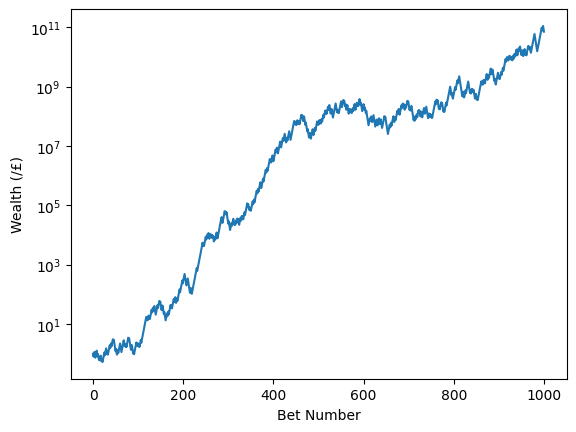

In [ ]:
import random
import matplotlib.pyplot as graph

p = 0.6
f = 0.2
wealth = 1.0
history =[wealth]

for i in range(1000):
  if random.random() < p:
    wealth = wealth * (1 + f)
  else:
    wealth = wealth * (1 - f)
  history.append(wealth)

graph.plot(history)
graph.xlabel("Bet Number")
graph.ylabel("Wealth (/£)")
graph.yscale("log")
graph.show()

In [27]:
import random
import statistics

p = 0.6
n_bets = 200
n_runs = 1000

def final_wealth(f):
  wealth = 1.0
  for i in range(n_bets):
    if random.random() < p:
      wealth = wealth * (1 + f)
    else:
      wealth = wealth * (1 - f)
  return wealth

for f in [0.1, 0.2, 0.4, 0.6, 0.8, 0.9]:
  results = [final_wealth(f) for runs in range(n_runs)]
  print(f, "mean:", statistics.mean(results), "median:", statistics.median(results))

0.1 mean: 51.93426485854723 median: 20.254567504427996
0.2 mean: 2040.584418074716 median: 84.14721447991164
0.4 mean: 2349828.9103457252 median: 0.6130054166833179
0.6 mean: 12863.248683225886 median: 4.5624406176222494e-08
0.8 mean: 4.606947629570648e-07 median: 5.189198280593653e-26
0.9 mean: 3.84958668321473e-22 median: 2.821188561557941e-47


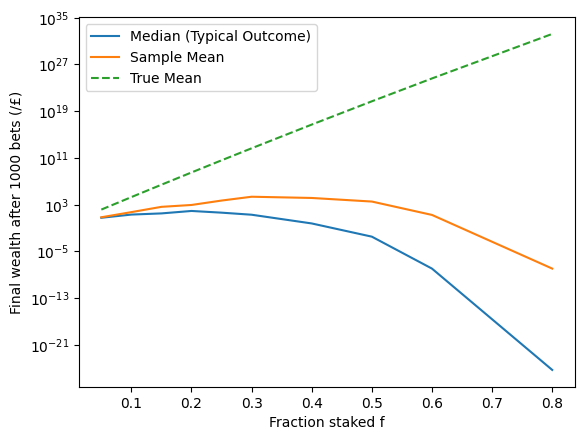

In [34]:
import matplotlib.pyplot as graph

TrialF = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.8]
means, medians = [], []
n_runs = 500

for f in TrialF:
    results = [final_wealth(f) for runs in range(n_runs)]
    means.append(statistics.mean(results))
    medians.append(statistics.median(results))

theory_mean = [(1 + 0.2*f)**500 for f in TrialF]

graph.plot(TrialF, medians, label= "Median (Typical Outcome)")
graph.plot(TrialF, means, label="Sample Mean")
graph.plot(TrialF, theory_mean, "--", label="True Mean")
graph.yscale("log")
graph.xlabel("Fraction staked f")
graph.ylabel("Final wealth after 1000 bets (/£)")
graph.legend()
graph.show()